# RCNN Surface-Code Decoder — Experiments Log
### d = 5, p = 0.01, r = 3  ·  RCNN-vs-MWPM convergence study  ·  Fermilab EAF

A dated lab-notebook of every run. For each experiment: **goal, what changed, config,
data params, results (table + plot), and file locations.** Plus a **glossary** (what each
term/parameter *does*) and a **script reference**.

*Run all cells to render the tables and figures (needs `pandas` + `matplotlib`).*
The numbers are hardcoded from the run logs so this notebook is self-contained.


## Glossary — terms & parameters (what each one *does*)

| Term | What it is / what it does |
|---|---|
| **`p_L`** (logical error rate) | Fraction of test shots the decoder gets wrong. The core metric. **Lower = better.** |
| **`n_test`** (test tail / hold-out set) | How many shots are **held out for evaluation only** (never trained on). Bigger `n_test` = more precise `p_L` measurement (`±√(p(1−p)/n_test)`). The tail is the **last** `n_test` shots of the pool. |
| **`n_train`** | How many shots the model **trains on** (the x-axis of the ladder: 100k→10M). |
| **tail (fixed) / nested prefixes** | Every rung trains on the **first** `n_train` shots and is scored on the **same last `n_test`** shots — so the curve reflects training size only, and train never overlaps test. |
| **MWPM** | Minimum-Weight Perfect Matching — the standard **classical** decoder (PyMatching). *Not trained*; its `p_L` does **not** improve with more data. The bar to match/beat. |
| **parity** | RCNN `p_L` = MWPM `p_L` (ratio = 1.0). **ratio < 1 = RCNN beats MWPM.** |
| **ratio (×MWPM)** | `RCNN p_L ÷ MWPM p_L`. 4.99× = 5× worse; 1.00× = tie; 0.95× = 5% better. |
| **seed** | RNG for one training run (init weights, shuffle order). Different seed → a different trained model. |
| **`sem_seed`** (SEM) | Spread of `p_L` **across seeds** ÷ √n. Measures **training/convergence noise**. Shrinks with **more seeds**. |
| **`binom_sig`** (binomial / test-set noise) | `√(p(1−p)/n_test)`. Measures **evaluation noise**. Shrinks with a **bigger tail**. |
| **combined error** | `√(sem_seed² + binom_sig²)` — the honest ± on each point. |
| **`d` / `p` / `r`** | Code distance / physical error rate / syndrome rounds. |
| **threshold (~0.0065)** | Below it, larger `d` lowers `p_L`. We run at **p = 0.01 > threshold** (*above* threshold). |
| **4-channel noise** | The 4 Stim noise channels (data-depol, reset-flip, Clifford-depol, measure-flip), all = `p`. |
| **base rate** | Error of the all-zero predictor (~0.28). A decoder must beat this (no "class collapse"). |
| **McNemar test** | Paired significance test: on the *shared* tail, does RCNN win more shots than MWPM? Uses per-shot outcomes; independent of seed scatter. |
| **XLA compile** | TF's one-time kernel compile on epoch 1 (~130 s); later epochs are fast. |
| **MIG** | The A100 is partitioned; the pod gets a ~10 GB / 14-SM slice (~1/7 card). |


## Script reference — what each file does

| Script | What it does |
|---|---|
| **`generate_datasets.py`** | Stim-samples a pool of shots for `(d, p, rounds, n_samples)` → `data_d{d}_p{p:.3f}_r{r}.npz` (measurements, det_evts, flips). CPU. `--rounds 3` is the key flag. |
| **`mwpm_on_pool.py`** | Decodes the pool's fixed tail with MWPM (PyMatching) → the baseline `p_L`; appends a row to `mwpm_baseline.csv`. |
| **`train_one.py`** | Trains ONE RCNN point `(d, p, seed, n_train)` on the fixed tail; writes a result CSV + history JSON. `--save-weights` keeps the model (`.weights.h5`). `lookup_mwpm` now matches on rounds. |
| **`run_ladder.sh`** | Driver: runs the whole 18-point ladder (6 sizes × 3 seeds), resume-safe. |
| **`collate_ladder.py`** | Aggregates per-run CSVs → mean±SEM per rung + a basic figure. |
| **`plot_pl_vs_n_gpu_v2.py`** | The honest-uncertainty figure: per-seed scatter + mean with **combined** error bars + MWPM **band**; prints the table. |
| **`eval_on_tail.py`** | Loads a saved model and re-scores it on ANY tail (no retrain). `--mcnemar` adds the paired 2×2 (both-right / RCNN-only / MWPM-only / both-wrong) + McNemar test. |


## Shared configuration (all experiments unless noted)

| Parameter | Value | | Parameter | Value |
|---|---|---|---|---|
| distance `d` | 5 | | epochs | 50 (no early stopping) |
| phys. error `p` | 0.010 (above threshold) | | batch size | 10,000 |
| rounds `r` | 3 (the reference architecture's ref config) | | val split | 0.2 |
| circuit | `surface_code:rotated_memory_z`, obs `ZL` | | LR schedule | the reference architecture's (warm-up ramp → decay) |
| noise | 4-channel, all = `p` | | kernel | 3 |
| n_params | 51,547 | | hidden / layers | 100 / 2 |
| pool seed | 42 | | npol | 2 |

**What changes between experiments:** the **test tail `n_test`** (10k → 200k) and which
rungs/seeds are run. That's the whole story — same model, different measurement precision.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,
                     "grid.alpha":0.3,"axes.axisbelow":True})
BLUE, GREEN = "#1f77b4", "#2ca02c"

def show_ladder(N, mean_pL, comb_err, ratio, mwpm, band, title):
    N = np.array(N, float)
    fig, ax = plt.subplots(figsize=(8,5))
    ax.axhline(mwpm, color=GREEN, ls="--", lw=2, label=f"MWPM = {mwpm:.4f}")
    ax.fill_between([N.min()*0.8, N.max()*1.25], mwpm-band, mwpm+band,
                    color=GREEN, alpha=0.15)
    ax.errorbar(N, mean_pL, yerr=comb_err, color=BLUE, lw=2, marker="o", ms=6,
                capsize=4, label="RCNN mean $\\pm$ combined err")
    for x,y,r in zip(N, mean_pL, ratio):
        ax.annotate(f"{r:.2f}x",(x,y),textcoords="offset points",xytext=(-11,11),
                    ha="right",va="bottom",fontsize=8.5,color=BLUE)
    ax.set_xscale("log"); ax.set_xlabel("n_train (log scale)")
    ax.set_ylabel("logical error rate  $p_L$   (lower = better)")
    ax.set_title(title); ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


---
## Experiment 0 — (prior) · Original CPU ladder — 5 seeds, 200k tail

- **Goal:** the original convergence ladder this whole study *reproduces* (run on CPU, before EAF).
- **Config:** **5 seeds**, 100k→5M (5 points), **200k test tail**, MWPM **0.0492**.
- **Result:** monotonic descent → **parity 0.99× at 5M** (p_L ~0.0487 vs MWPM 0.0492).
- **Figure:** `plots/rcnn_d5_pl_vs_n_v2.png`
- **Why it matters (the reframe):** it *already* used a **200k tail + 5 seeds**, and its MWPM
  (0.0492) matches the EAF 200k value (0.04875) — so this original result was **sound**. The
  test-tail history across experiments is: **200k (CPU, Exp 0) → 10k (EAF, Exp 1 — a coarse
  *regression*) → 200k (EAF, Exp 2/3 — restored + extended to 10M)**. The EAF-10k "parity
  unresolvable" confusion was the anomaly; the 200k runs bracket it and agree.
- *Numbers below are read from the figure (ratios) — exact per-rung SEM lives in the original CSVs.*


In [22]:
exp0 = pd.DataFrame({
 "n_train":[100_000,300_000,800_000,2_000_000,5_000_000],
 "mean_pL_approx":[0.2032,0.1319,0.0841,0.0541,0.0487],
 "xMWPM":[4.13,2.68,1.71,1.10,0.99],
 "seeds":[5,5,5,5,5]})
exp0  # MWPM=0.0492, 200k tail, CPU; p_L approx from figure ratios

,n_train,mean_pL_approx,xMWPM,seeds
0,100000,0.2032,4.13,5
1,300000,0.1319,2.68,5
2,800000,0.0841,1.71,5
3,2000000,0.0541,1.10,5
4,5000000,0.0487,0.99,5


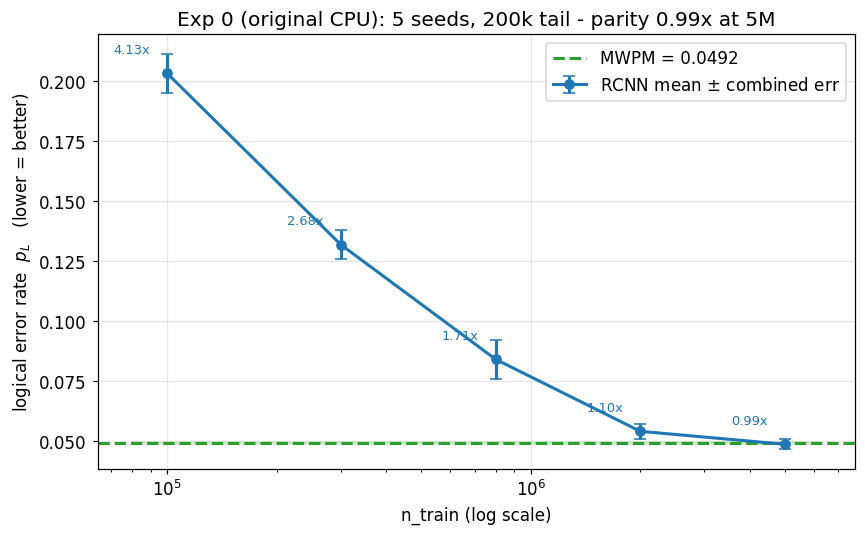

In [23]:
show_ladder(exp0.n_train, exp0.mean_pL_approx, [0.008,0.006,0.008,0.003,0.002],
            exp0.xMWPM, mwpm=0.0492, band=0.0005,
            title="Exp 0 (original CPU): 5 seeds, 200k tail - parity 0.99x at 5M")

---
## Experiment 1 — 2026-06-30 · 10k-tail full ladder (baseline pass)

- **Goal:** reproduce the reference architecture's `p_L`-vs-`n_train` learning curve on EAF and extend to a
  new **10M** point.
- **What changed:** first full run on EAF; **`n_test = 10,000`** tail.
- **Runs:** 6 sizes × 3 seeds = **18 runs**, single 10.01M-shot pool.
- **MWPM anchor:** **0.04510** (10k tail) → ±0.0021.
- **Result:** clean monotonic descent; 10M read **1.002×** — i.e. parity, but the gap
  (~0.0001) was **smaller than the noise (~0.002)** → *unresolvable*.
- **Files:** results `~/rcnn_threshold/out/rcnn_d5_p0.010_r3_seed*_ntr*.csv` · pool
  `~/rcnn_threshold/pools/data_d5_p0.010_r3.npz` · figure `plots/rcnn_d5_pl_vs_n_gpu_v2.png`


In [24]:
exp1 = pd.DataFrame({
 "n_train":[100_000,300_000,800_000,2_000_000,5_000_000,10_000_000],
 "mean_pL":[0.22517,0.13560,0.08063,0.05577,0.04887,0.04520],
 "sem_seed":[0.01049,0.00546,0.00192,0.00387,0.00096,0.00061],
 "binom_sig":[0.00418,0.00342,0.00272,0.00229,0.00216,0.00208],
 "comb_err":[0.01129,0.00644,0.00333,0.00450,0.00236,0.00216],
 "xMWPM":[4.993,3.007,1.788,1.237,1.084,1.002]})
exp1

,n_train,mean_pL,sem_seed,binom_sig,comb_err,xMWPM
0,100000,0.22517,0.01049,0.00418,0.01129,4.993
1,300000,0.13560,0.00546,0.00342,0.00644,3.007
2,800000,0.08063,0.00192,0.00272,0.00333,1.788
3,2000000,0.05577,0.00387,0.00229,0.00450,1.237
4,5000000,0.04887,0.00096,0.00216,0.00236,1.084
5,10000000,0.04520,0.00061,0.00208,0.00216,1.002


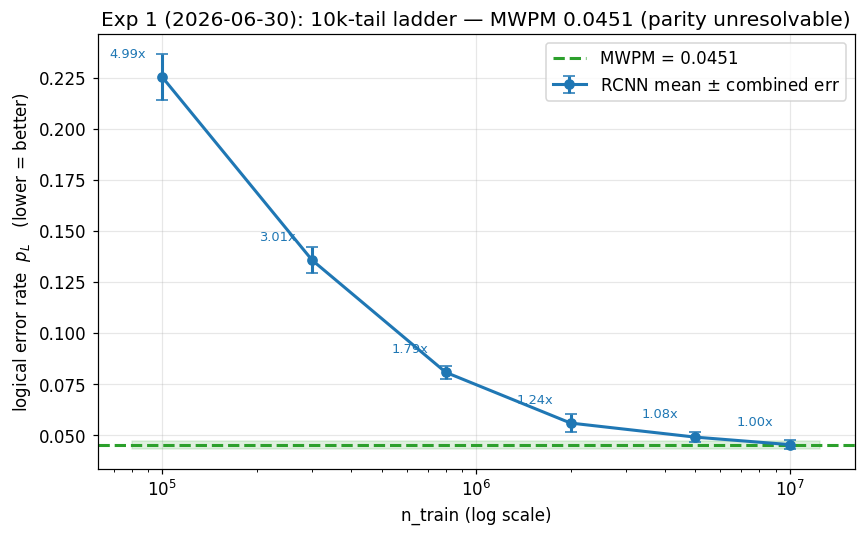

In [25]:
show_ladder(exp1.n_train, exp1.mean_pL, exp1.comb_err, exp1.xMWPM,
            mwpm=0.04510, band=0.00208,
            title="Exp 1 (2026-06-30): 10k-tail ladder — MWPM 0.0451 (parity unresolvable)")

---
## Experiment 2 — 2026-07-01 · 200k-tail parity re-measurement (5M & 10M)

- **Goal:** resolve the parity question — is 10M *at* or *below* MWPM?
- **What changed:** **`n_test = 200,000`** tail (~4.5× more precise); a fresh 10.2M pool
  (`pools_t200k`). Retrained 5M & 10M × 3 seeds (weights **not** saved — cost a later retrain).
- **MWPM anchor:** **0.04875 ± 0.00048** (the 10k 0.0451 was a low-outlier draw; the true
  MWPM ≈ 0.049 matches the original CPU run).
- **Result:** **5M = 0.998× (parity); 10M = 0.949× → BEATS MWPM by ~5%, ~3σ**, all 3 seeds
  below (0.04643 / 0.04562 / 0.04678). The beat was invisible on the 10k tail.
- **Files:** `~/rcnn_threshold/out_t200k/…` · pool `~/rcnn_threshold/pools_t200k/…` ·
  baseline `pools_t200k/mwpm_baseline.csv`


In [26]:
exp2 = pd.DataFrame({
 "n_train":[5_000_000,10_000_000],
 "mean_pL":[0.04867,0.04628],
 "sem_seed":[0.00048,0.00034],
 "binom_sig":[0.00048,0.00047],
 "comb_err":[0.00068,0.00058],
 "xMWPM":[0.998,0.949],
 "verdict":["parity","beats MWPM ~5%"]})
exp2

,n_train,mean_pL,sem_seed,binom_sig,comb_err,xMWPM,verdict
0,5000000,0.04867,0.00048,0.00048,0.00068,0.998,parity
1,10000000,0.04628,0.00034,0.00047,0.00058,0.949,beats MWPM ~5%


In [27]:
# per-seed 10M values (all below MWPM 0.04875)
pd.DataFrame({"seed":[0,1,2],"pL_10M":[0.04643,0.04562,0.04678]})

,seed,pL_10M
0,0,0.04643
1,1,0.04562
2,2,0.04678


---
## Experiment 3 — 2026-07-02 · 200k-tail FULL ladder (presentation figure)

- **Goal:** the complete 100k→10M descent, every rung on the precise 200k tail (consistent,
  publishable figure).
- **What changed:** retrained the 4 lower rungs (100k–2M) × 3 seeds on the 200k tail; joined
  with Exp 2's 5M/10M. **18 runs total** in `out_t200k`.
- **MWPM anchor:** **0.04875 ± 0.00048**.
- **Result:** monotonic **4.06× → 0.95×**; parity at 5M, beats MWPM at 10M. Whole curve sits
  closer to parity than Exp 1 — because the *true* MWPM (0.04875) replaced the low 0.0451 in
  the denominator (not a model change).
- **Files:** `~/rcnn_threshold/out_t200k/…` · **figure `plots/rcnn_d5_pl_vs_n_t200k_full.png`**


In [28]:
exp3 = pd.DataFrame({
 "n_train":[100_000,300_000,800_000,2_000_000,5_000_000,10_000_000],
 "mean_pL":[0.19814,0.14341,0.07485,0.05331,0.04867,0.04628],
 "sem_seed":[0.00257,0.00725,0.00314,0.00032,0.00048,0.00034],
 "binom_sig":[0.00089,0.00078,0.00059,0.00050,0.00048,0.00047],
 "comb_err":[0.00272,0.00729,0.00319,0.00060,0.00068,0.00058],
 "xMWPM":[4.06,2.94,1.54,1.09,0.998,0.949]})
exp3

,n_train,mean_pL,sem_seed,binom_sig,comb_err,xMWPM
0,100000,0.19814,0.00257,0.00089,0.00272,4.060
1,300000,0.14341,0.00725,0.00078,0.00729,2.940
2,800000,0.07485,0.00314,0.00059,0.00319,1.540
3,2000000,0.05331,0.00032,0.00050,0.00060,1.090
4,5000000,0.04867,0.00048,0.00048,0.00068,0.998
5,10000000,0.04628,0.00034,0.00047,0.00058,0.949


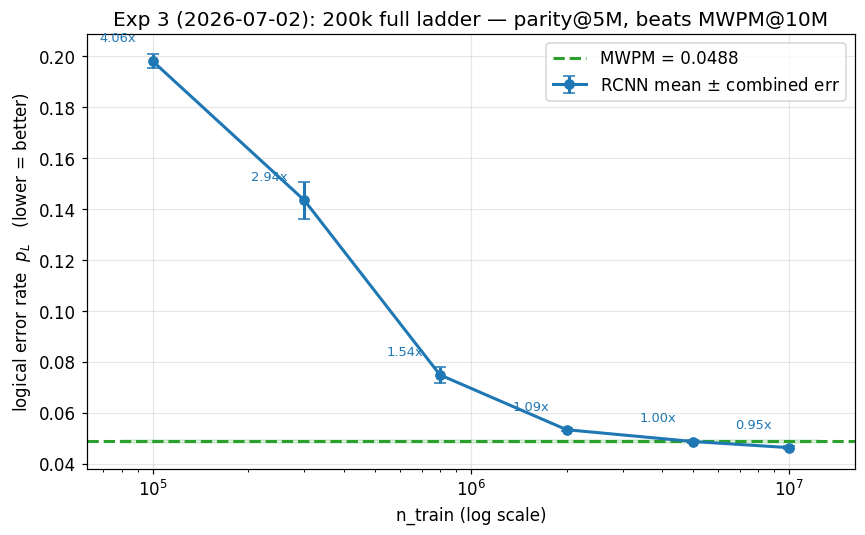

In [29]:
show_ladder(exp3.n_train, exp3.mean_pL, exp3.comb_err, exp3.xMWPM,
            mwpm=0.04875, band=0.00048,
            title="Exp 3 (2026-07-02): 200k full ladder — parity@5M, beats MWPM@10M")

---
## Experiment 4 — 2026-07-02 · Weights retrain + McNemar (IN PROGRESS / PENDING)

- **Goal:** make the 10M beat **reviewer-proof** — a paired McNemar test on the shared 200k
  tail, per seed, plus reusable saved weights.
- **What changed:** `train_one.py` now really saves weights (`--save-weights`); retraining
  **10M × 3 seeds with weights** into `out_t200k_w/`. Then `eval_on_tail.py --mcnemar`.
- **Why it needs a retrain:** the Exp 2/3 models were trained without `--save-weights`, so the
  networks are gone — McNemar needs per-shot predictions, which need the model.
- **What McNemar reports (raw counts stored, not just a p-value):** both-right / **RCNN-only**
  / **MWPM-only** / both-wrong; `net_rcnn_wins = n_test × (p_L_MWPM − p_L_RCNN)`; χ² + exact p.
  The discordant cells (RCNN-only vs MWPM-only) are the *science* — how it wins.
- **Status:** _pending — fill in the 2×2 counts + p-values here when the retrain + eval finish._
- **Files:** `~/rcnn_threshold/out_t200k_w/…` · McNemar CSV `out_t200k_w/mcnemar.csv`


---
## Experiment 5 — 2026-07-04..06 · 20M point — does it keep improving? (PLATEAU)

- **Goal:** push training to 20M shots — does the RCNN keep descending past 10M (data-limited)
  or flatten (structural floor)?
- **Config:** 20M × 3 seeds, fresh **20.2M pool** (`pools_20M`, 200k tail), MWPM **0.04909**,
  `--save-weights` (McNemar free). Same recipe as the ladder.
- **Result:** mean **0.04765 (0.971×), ±0.0025** — **NO improvement over 10M** (0.04628, 0.949×);
  if anything slightly worse, within the large error bar. **Seed spread blew up ~5×** (0.0012 @10M
  → 0.0042 @20M).
- **Per-seed:** 0.04591 (0.935×, beats), **0.05246 (1.068×, LOSES to MWPM — convergence outlier)**,
  0.04458 (0.908×, best).
- **McNemar (per-shot, paired, weights saved):** seed0 net **+636** (p=4.5e-15, beat); seed1 net
  **−673** (p=5.0e-14, **MWPM wins**); seed2 net **+902** (p=3.7e-29, beat). **2 of 3 beat MWPM,
  1 loses — each individually significant**, so the split is *real convergence variance*, not noise.
- **Conclusion:** the RCNN hits a **structural floor ~5% below MWPM by ~10M**; 20M shows **no
  further gain + rising convergence instability** (1/3 retrainings land worse than MWPM). Answer to
  "does it converge": **plateau, not data-limited.**
- **Files:** `out_20M`, `pools_20M`, `out_20M/mcnemar_20M.csv`, figure
  `plots/rcnn_d5_pl_vs_n_100k_20M.png` (via `plot_ladder_merged.py`).


In [30]:
exp5 = pd.DataFrame({
 "seed":[0,1,2], "pL_20M":[0.04591,0.05246,0.04458], "xMWPM":[0.935,1.068,0.908],
 "mcnemar_net_wins":[636,-673,902], "mcnemar_p":[4.5e-15,5.0e-14,3.7e-29],
 "verdict":["beats MWPM","LOSES to MWPM","beats MWPM"]})
exp5  # 20M mean p_L=0.04765 (0.971x) +/-0.0025 vs MWPM 0.04909 -- NO gain over 10M

,seed,pL_20M,xMWPM,mcnemar_net_wins,mcnemar_p,verdict
0,0,0.04591,0.935,636,4.500000e-15,beats MWPM
1,1,0.05246,1.068,-673,5.000000e-14,LOSES to MWPM
2,2,0.04458,0.908,902,3.700000e-29,beats MWPM


### McNemar test — settling "does this model beat MWPM?" without leaning on seed count

3 seeds is a weak basis for a seed-scatter test. **McNemar** sidesteps it: both decoders are scored
on the SAME 200k shots, so per shot we know if each was right. It looks only at the DISCORDANT shots
(exactly one decoder right):
- **RCNN-only** (RCNN right, MWPM wrong) = RCNN wins that shot
- **MWPM-only** (MWPM right, RCNN wrong) = MWPM wins

Under "no difference" these are equal; an imbalance is significant. Thousands of discordant shots per
model → huge power, per-model, no seed-count dependence. Identity: net wins = RCNN-only − MWPM-only =
n_test × (p_L_MWPM − p_L_RCNN), exactly. **20M:** 2 of 3 models win decisively (p≈1e-15, 1e-29); seed1
LOSES (p≈1e-14) — the split is real, not noise.

In [31]:
mcnemar20 = pd.DataFrame({
 "seed":[0,1,2],
 "both_right":[187215,185860,187392],
 "RCNN_only":[3603,3649,3692],
 "MWPM_only":[2967,4322,2790],
 "both_wrong":[6215,6169,6126],
 "net_RCNN_wins":[636,-673,902],
 "p_exact":[4.5e-15,5.0e-14,3.7e-29],
 "verdict":["RCNN beats","MWPM beats","RCNN beats"]})
mcnemar20  # discordant cells (RCNN-only vs MWPM-only) are the science

,seed,both_right,RCNN_only,MWPM_only,both_wrong,net_RCNN_wins,p_exact,verdict
0,0,187215,3603,2967,6215,636,4.500000e-15,RCNN beats
1,1,185860,3649,4322,6169,-673,5.000000e-14,MWPM beats
2,2,187392,3692,2790,6126,902,3.700000e-29,RCNN beats


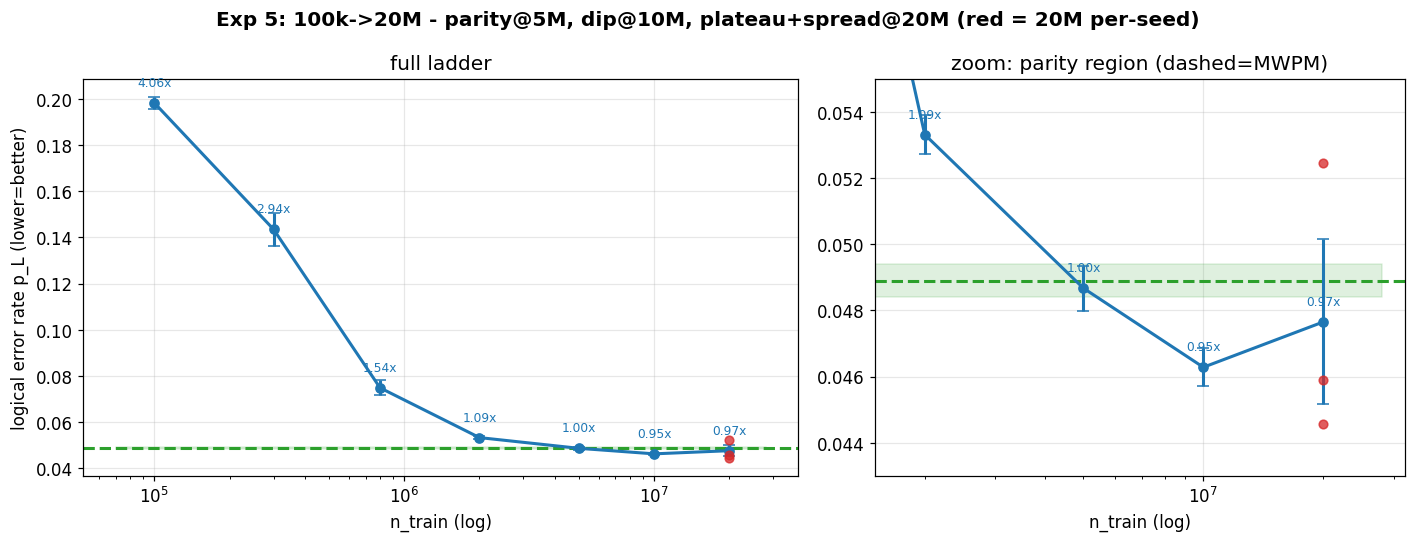

In [32]:
# two-panel: full ladder (left) + zoom on the parity region (right)
import matplotlib.pyplot as plt
N=np.array([1e5,3e5,8e5,2e6,5e6,1e7,2e7])
pL=np.array([0.19814,0.14341,0.07485,0.05331,0.04867,0.04628,0.04765])
err=np.array([0.00272,0.00729,0.00319,0.00060,0.00068,0.00058,0.00249])
ratio=[4.06,2.94,1.54,1.09,1.00,0.95,0.97]; seeds20=[0.04591,0.05246,0.04458]
mwpm=0.0489; band=0.0005
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,5),gridspec_kw={"width_ratios":[1.35,1]})
for ax in (a1,a2):
    ax.axhline(mwpm,color=GREEN,ls="--",lw=2)
    ax.fill_between([N.min()*0.7,N.max()*1.4],mwpm-band,mwpm+band,color=GREEN,alpha=0.15)
    ax.errorbar(N,pL,yerr=err,color=BLUE,lw=2,marker="o",ms=6,capsize=4)
    ax.scatter([2e7]*3,seeds20,color="#d62728",alpha=0.75,s=32,zorder=5)
    for x,y,rr in zip(N,pL,ratio):
        ax.annotate(f"{rr:.2f}x",(x,y),textcoords="offset points",xytext=(0,11),ha="center",fontsize=8,color=BLUE)
    ax.set_xscale("log"); ax.set_xlabel("n_train (log)"); ax.grid(True,alpha=0.3)
a1.set_ylabel("logical error rate p_L (lower=better)"); a1.set_title("full ladder")
a2.set_xlim(1.5e6,3.2e7); a2.set_ylim(0.043,0.055); a2.set_title("zoom: parity region (dashed=MWPM)")
fig.suptitle("Exp 5: 100k->20M - parity@5M, dip@10M, plateau+spread@20M (red = 20M per-seed)",fontweight="bold")
plt.tight_layout(); plt.show()

---
## Cross-experiment notes (for the write-up)

- **The model never changed** between experiments — only the **test tail** (10k→200k). The
  RCNN's `p_L` reproduced across CPU↔EAF and across tails; what moved was **measurement
  precision** and the **MWPM baseline estimate**.
- **The MWPM anchor drifts by tail** (0.0451 @10k, 0.04875 @200k) because it's estimated on a
  finite sample; the 200k value is the trustworthy one (~0.049, matches the original CPU run).
  → *Only compare RCNN and MWPM measured on the SAME tail.*
- **Two noise sources, two knobs:** seed spread (`sem_seed`) = training noise, fixed by *more
  seeds*; binomial (`binom_sig`) = eval noise, fixed by a *bigger tail*.
- **Lesson banked:** for comparison studies, use a big tail from the start **and**
  `--save-weights` — else re-measuring costs a full retrain (Exp 4 exists only because Exp 2/3
  didn't save weights).
- **Scope:** one **above-threshold** point (d=5, p=0.01, r=3). Not a scaling or below-threshold
  claim — those (d=3,5,7 sweep, sub-threshold) are the higher-value next experiments.
